In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path("..").resolve()
metrics_dir = BASE_DIR / "results" / "metrics"

In [3]:
def load_json(name):
    with open(metrics_dir / name, "r") as f:
        return json.load(f)

In [4]:
ml = load_json("ml_results.json")          # Liste mit 3 Modellen
bert = load_json("bert_results.json")      # Dict
hyb = load_json("hybrid_results.json")  

In [5]:
rows = []

for m in ml:
    rows.append({
        "model": m["model"],
        "accuracy": m["accuracy"],
        "f1": m["f1"],
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"],
    })


In [6]:
rows.append({"model": "BERT", **bert})
rows.append({"model": "Hybrid_LGBM+BERT", **hyb})

In [7]:
df = pd.DataFrame(rows)
display(df)


,model,accuracy,f1,roc_auc,pr_auc
0,RandomForest,0.885695,0.784702,0.934956,0.883343
1,XGBoost,0.875501,0.753007,0.920333,0.866253
2,LightGBM,0.877916,0.759521,0.923993,0.871285
3,BERT,0.960207,0.927108,0.991923,0.983440
4,Hybrid_LGBM+BERT,0.963640,0.935945,0.990126,0.981444


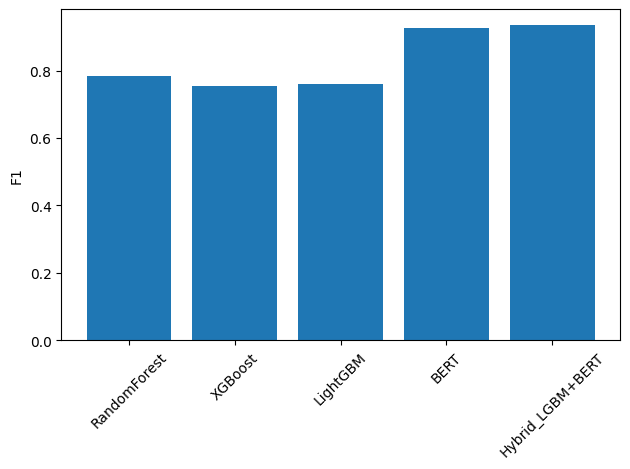

In [8]:
# Balkendiagramm F1
plt.figure()
plt.bar(df["model"], df["f1"])
plt.ylabel("F1")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

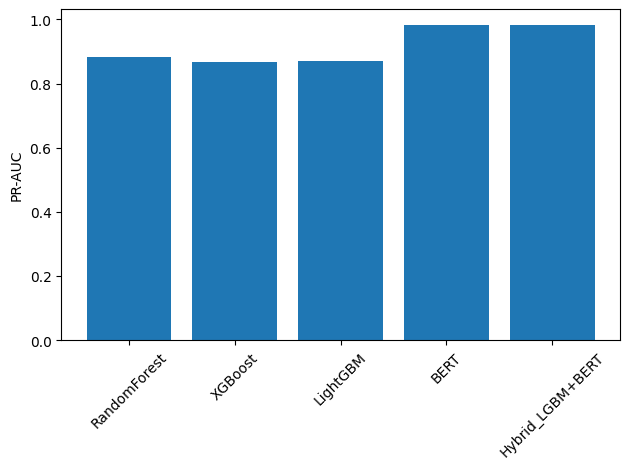

In [9]:
# Balkendiagramm PR-AUC
plt.figure()
plt.bar(df["model"], df["pr_auc"])
plt.ylabel("PR-AUC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()